# Capa 2 · ¿Causó el COVID el aumento de las *patologías* psiquiátricas?
### Quiebre de tendencia sobre egresos hospitalarios por diagnóstico CIE-10 (F00-F99)

**Por qué esta capa.** La Capa 1 (REM20) midió la **hospitalización** psiquiátrica — camas,
egresos, ocupación — pero **no el diagnóstico**. No podía distinguir si lo que aumentó fue la
*enfermedad* o solo el *uso de camas*. Esta Capa 2 usa una fuente con **diagnóstico clínico**:
los **egresos hospitalarios del DEIS/MINSAL**, que traen el diagnóstico principal en **CIE-10**.
Aislamos el **capítulo V (F00-F99, trastornos mentales y del comportamiento)** y preguntamos lo
mismo: ¿el alza de patología psiquiátrica fue *causada* por el COVID o ya era tendencia previa?

**Salvedades metodológicas (honestidad del dato).**
- La base DEIS es de granularidad **ANUAL** (`ANO_EGRESO`, sin mes), así que la serie es anual
  (~25 puntos, 2001-2025). El quiebre es más **grueso** que la Capa 1 mensual.
- Un egreso con diagnóstico F es una **hospitalización por trastorno mental**, no la
  **incidencia poblacional** de la enfermedad (para eso harían falta datos ambulatorios o
  encuestas como la ENS). Medimos *hospitalización por diagnóstico*, no *prevalencia*.
- El **2025 puede ser un año parcial/preliminar** (carga incompleta); se marca y se excluye del
  ajuste de tendencia si los datos lo sugieren.

**Fuente:** DEIS/MINSAL, egresos hospitalarios datos abiertos, CIE-10 DIAG1. ETL:
`python/scripts/07_ingesta_egresos_deis.py`.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / '.env').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROC = ROOT / 'data' / 'processed'
GRAF = PROC / 'graficos_patologias'
GRAF.mkdir(parents=True, exist_ok=True)

COVID_Y = 2020     # anio de interrupcion
POST_Y  = 2022     # inicio fase post-aguda

GRUPOS = {
    'F0': 'F00-F09 Organicos (demencia)', 'F1': 'F10-F19 Sustancias',
    'F2': 'F20-F29 Esquizofrenia/psicoticos', 'F3': 'F30-F39 Afectivos (depresion/bipolar)',
    'F4': 'F40-F48 Ansiedad/estres', 'F5': 'F50-F59 Sind. comportamentales',
    'F6': 'F60-F69 Personalidad', 'F7': 'F70-F79 Discap. intelectual',
    'F8': 'F80-F89 Desarrollo', 'F9': 'F90-F99 Infancia/adolesc. y sin esp.'}

plt.rcParams.update({'figure.figsize': (12, 6), 'axes.grid': True,
                     'grid.alpha': 0.25, 'font.size': 11})
PIE = 'Fuente: DEIS/MINSAL, egresos hospitalarios CIE-10 (F00-F99), 2001-2025'
def pie(ax):
    ax.annotate(PIE, xy=(0.99, -0.13), xycoords='axes fraction', ha='right',
                va='top', fontsize=8, color='gray')
print('Proyecto:', ROOT)

Proyecto: C:\Users\matia\Memoria\proyectos\Analisis_Hospitalario


## Sección 1 · Serie anual de egresos por trastorno mental (2001-2025)

`egresos_sm` = egresos con diagnóstico principal F00-F99. Se mira también la **tasa** (egresos
de salud mental por cada 10.000 egresos hospitalarios totales): controla por el tamaño global
de la actividad hospitalaria, clave porque en 2020 el total de egresos **se desplomó** por la
suspensión de cirugías electivas.

In [2]:
serie = pd.read_csv(PROC / 'serie_anual_salud_mental.csv', sep=';')
serie = serie.sort_values('ano').reset_index(drop=True)

# detectar anio parcial: si el ultimo anio cae mucho respecto del previo, marcarlo
ult = serie.iloc[-1]; prev = serie.iloc[-2]
parcial = ult['egresos_total'] < 0.7 * prev['egresos_total']
print('Ultimo anio:', int(ult['ano']), '| parcial/preliminar:', bool(parcial))

df = serie.copy()
if parcial:
    df = df[df['ano'] < ult['ano']].copy()
df['t'] = df['ano'] - df['ano'].min()
df['D'] = (df['ano'] >= COVID_Y).astype(int)
df['t_post'] = np.where(df['D'] == 1, df['ano'] - COVID_Y, 0)
df['egresos_no_sm'] = df['egresos_total'] - df['egresos_sm']
df[['ano', 'egresos_total', 'egresos_sm', 'tasa_sm_x10mil']].tail(12)

Ultimo anio: 2025 | parcial/preliminar: False


,ano,egresos_total,egresos_sm,tasa_sm_x10mil
13,2014,1660151,27769,167.268
14,2015,1671054,27908,167.008
15,2016,1637265,26949,164.598
16,2017,1637150,28703,175.323
17,2018,1669602,31253,187.188
18,2019,1667180,32695,196.110
19,2020,1330477,26299,197.666
20,2021,1467062,29446,200.714
21,2022,1597118,34798,217.880
22,2023,1612267,39874,247.316


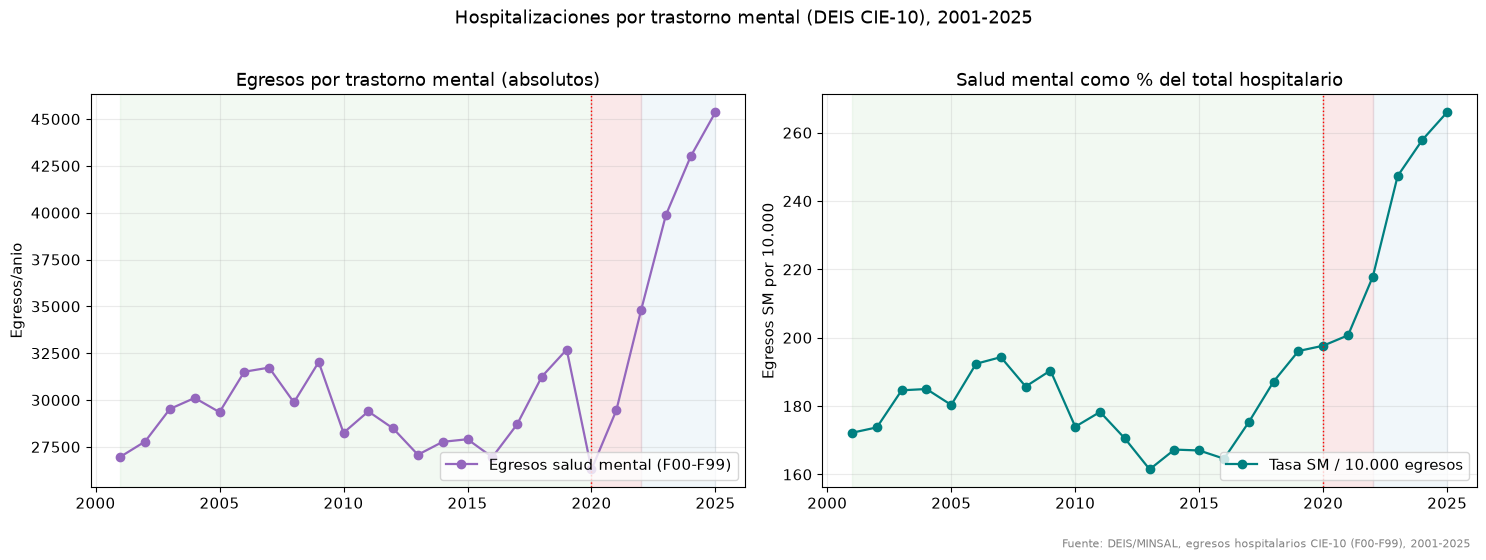

In [3]:
def zonas(ax, df):
    ax.axvspan(df['ano'].min(), COVID_Y, color='tab:green', alpha=0.06)
    ax.axvspan(COVID_Y, POST_Y, color='tab:red', alpha=0.10)
    ax.axvspan(POST_Y, df['ano'].max(), color='tab:blue', alpha=0.06)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
ax.plot(df['ano'], df['egresos_sm'], 'o-', color='tab:purple', lw=1.6, label='Egresos salud mental (F00-F99)')
zonas(ax, df); ax.axvline(COVID_Y, color='red', lw=1, ls=':')
ax.set_title('Egresos por trastorno mental (absolutos)'); ax.set_ylabel('Egresos/anio')
ax.legend(loc='lower right')
ax = axes[1]
ax.plot(df['ano'], df['tasa_sm_x10mil'], 'o-', color='teal', lw=1.6, label='Tasa SM / 10.000 egresos')
zonas(ax, df); ax.axvline(COVID_Y, color='red', lw=1, ls=':')
ax.set_title('Salud mental como % del total hospitalario'); ax.set_ylabel('Egresos SM por 10.000')
ax.legend(loc='lower right'); pie(ax)
fig.suptitle('Hospitalizaciones por trastorno mental (DEIS CIE-10), 2001-2025', y=1.02)
fig.tight_layout(); fig.savefig(GRAF / '01_serie_anual_sm.png', dpi=150, bbox_inches='tight')
plt.show()

## Sección 2 · Quiebre de tendencia (ITS anual)

Modelo de series temporales interrumpidas a resolución anual (sin estacionalidad, no aplica):

$$y_a = \beta_0 + \beta_1 t + \beta_2 D_a + \beta_3 (a-2020)D_a + \varepsilon_a$$

- $\beta_1$ = pendiente **pre-COVID** (¿la patología ya subía?)
- $\beta_2$ = cambio de **nivel** en 2020
- $\beta_3$ = cambio de **pendiente** posterior

Errores **HAC (Newey-West, maxlags=1)** por la autocorrelación. Test F conjunto sobre
$\beta_2,\beta_3$ = quiebre estructural en 2020.

In [4]:
def its(d, y):
    m = smf.ols(f"{y} ~ t + D + t_post", data=d).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
    pre = d[d['ano'] < COVID_Y]
    mp = smf.ols(f"{y} ~ t", data=pre).fit()
    ft = m.f_test("D = 0, t_post = 0")
    return m, mp, ft

filas = []
for y, u in [('egresos_sm', 'egresos/anio'), ('tasa_sm_x10mil', 'por 10.000')]:
    m, mp, ft = its(df, y)
    filas.append({'indicador': y, 'unidad': u,
        'pend_pre': round(mp.params['t'], 3), 'p_pre': round(mp.pvalues['t'], 4),
        'cambio_nivel': round(m.params['D'], 2), 'p_nivel': round(m.pvalues['D'], 4),
        'cambio_pend': round(m.params['t_post'], 3), 'p_pend': round(m.pvalues['t_post'], 4),
        'F_quiebre': round(float(np.ravel(ft.fvalue)[0]), 2), 'p_quiebre': round(float(ft.pvalue), 5)})
its_tab = pd.DataFrame(filas); its_tab

,indicador,unidad,pend_pre,p_pre,cambio_nivel,p_nivel,cambio_pend,p_pend,F_quiebre,p_quiebre
0,egresos_sm,egresos/anio,22.779,0.7737,-3177.19,0.0135,4009.164,0.0,211.67,0.0
1,tasa_sm_x10mil,por 10.000,-0.303,0.5077,16.54,0.0242,15.814,0.0,80.73,0.0


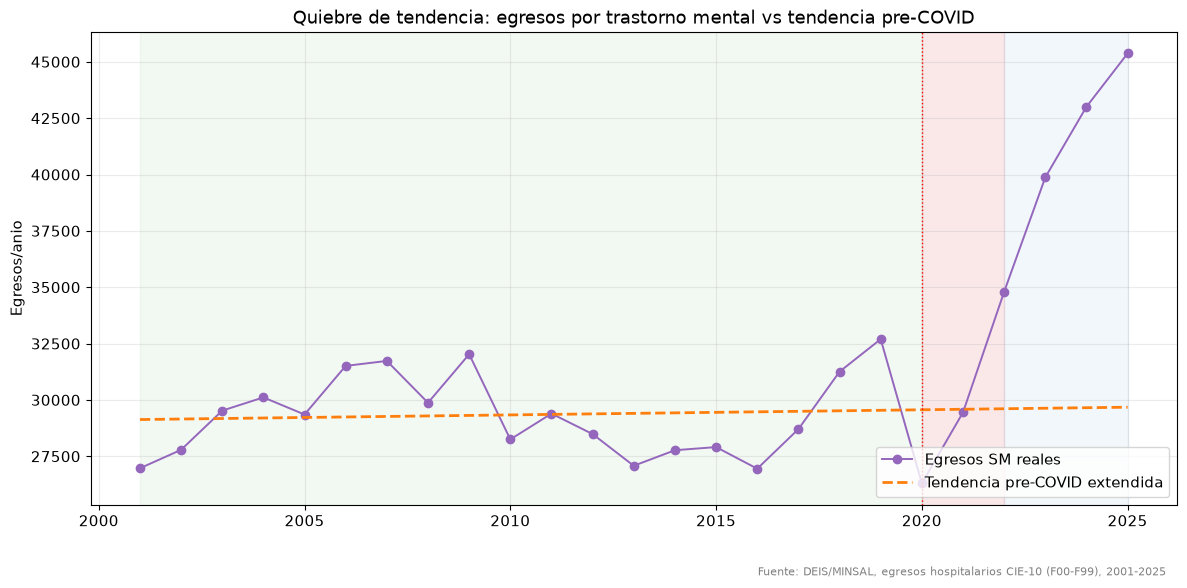

In [5]:
# Visual del quiebre: tendencia pre-COVID extendida vs real (egresos absolutos)
fig, ax = plt.subplots()
y = 'egresos_sm'
mp = smf.ols(f"{y} ~ t", data=df[df['ano'] < COVID_Y]).fit()
tend = mp.predict(df)
ax.plot(df['ano'], df[y], 'o-', color='tab:purple', lw=1.4, label='Egresos SM reales')
ax.plot(df['ano'], tend, '--', color='tab:orange', lw=2, label='Tendencia pre-COVID extendida')
zonas(ax, df); ax.axvline(COVID_Y, color='red', lw=1, ls=':')
ax.set_title('Quiebre de tendencia: egresos por trastorno mental vs tendencia pre-COVID')
ax.set_ylabel('Egresos/anio'); ax.legend(loc='lower right'); pie(ax)
fig.tight_layout(); fig.savefig(GRAF / '02_quiebre_tendencia_sm.png', dpi=150, bbox_inches='tight')
plt.show()

## Sección 3 · Contrafactual (proyección de la tendencia previa)

Se ajusta con **solo datos pre-COVID** y se proyecta a 2020+ *como si la pandemia no hubiera
ocurrido*. La **brecha** observado − contrafactual, con banda de predicción 95%, es el efecto
candidato atribuible al COVID.

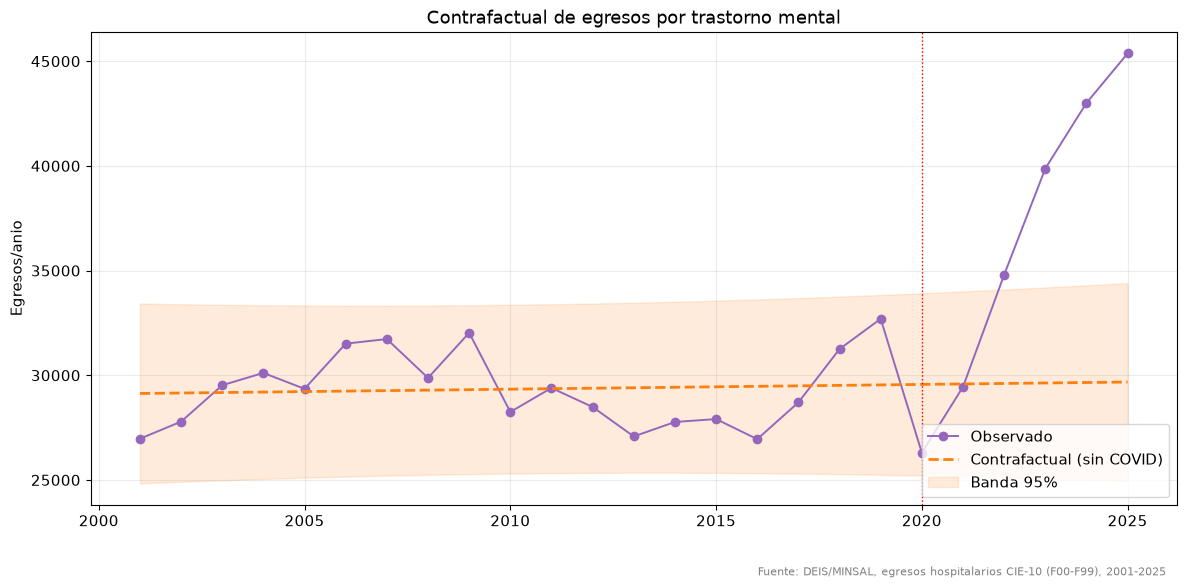

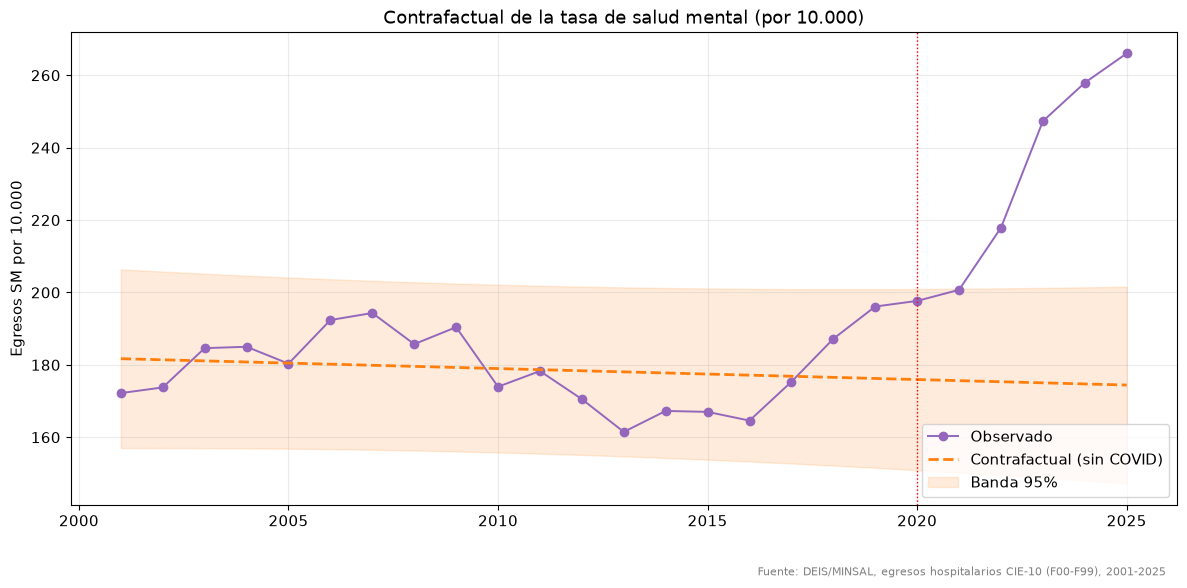

Egresos absolutos: {'brecha_covid': np.float64(-1701.9), 'brecha_post': np.float64(11119.5), 'post_vs_esperado_%': np.float64(37.5)}
Tasa (share)     : {'brecha_covid': np.float64(23.4), 'brecha_post': np.float64(72.4), 'post_vs_esperado_%': np.float64(41.4)}


In [6]:
def contrafactual(d, y):
    pre = d[d['ano'] < COVID_Y]
    m = smf.ols(f"{y} ~ t", data=pre).fit()
    pr = m.get_prediction(d).summary_frame(alpha=0.05)
    out = d[['ano', y]].copy()
    out['cf'] = pr['mean'].values
    out['lo'] = pr['obs_ci_lower'].values
    out['hi'] = pr['obs_ci_upper'].values
    out['gap'] = out[y] - out['cf']
    return out

def plot_cf(d, y, titulo, ylabel, fname):
    cf = contrafactual(d, y)
    fig, ax = plt.subplots()
    ax.plot(cf['ano'], cf[y], 'o-', color='tab:purple', lw=1.4, label='Observado')
    ax.plot(cf['ano'], cf['cf'], '--', color='tab:orange', lw=2, label='Contrafactual (sin COVID)')
    ax.fill_between(cf['ano'], cf['lo'], cf['hi'], color='tab:orange', alpha=0.15, label='Banda 95%')
    ax.axvline(COVID_Y, color='red', lw=1, ls=':')
    ax.set_title(titulo); ax.set_ylabel(ylabel); ax.legend(loc='lower right'); pie(ax)
    fig.tight_layout(); fig.savefig(GRAF / fname, dpi=150, bbox_inches='tight'); plt.show()
    covid = cf[(cf['ano'] >= COVID_Y) & (cf['ano'] < POST_Y)]
    post = cf[cf['ano'] >= POST_Y]
    return {'brecha_covid': round(covid['gap'].mean(), 1),
            'brecha_post': round(post['gap'].mean(), 1),
            'post_vs_esperado_%': round(100*post['gap'].mean()/post['cf'].mean(), 1)}

g_abs = plot_cf(df, 'egresos_sm', 'Contrafactual de egresos por trastorno mental',
                'Egresos/anio', '03_contrafactual_sm.png')
g_tasa = plot_cf(df, 'tasa_sm_x10mil', 'Contrafactual de la tasa de salud mental (por 10.000)',
                 'Egresos SM por 10.000', '04_contrafactual_tasa.png')
print('Egresos absolutos:', g_abs)
print('Tasa (share)     :', g_tasa)

## Sección 4 · Grupo de control y diferencias en diferencias

Control = egresos **NO** psiquiátricos (todo el resto del capítulo CIE-10). Si la salud mental
se desvió de su tendencia **más** que el resto del sistema, el comportamiento es específico de
salud mental. Comparación tipo *diferencias en diferencias* sobre la brecha post-COVID.

Salud mental   POST vs esperado: +37.5%
Resto sistema  POST vs esperado: -3.6%
Diff-in-diff (SM - control)    : +41.1 puntos %


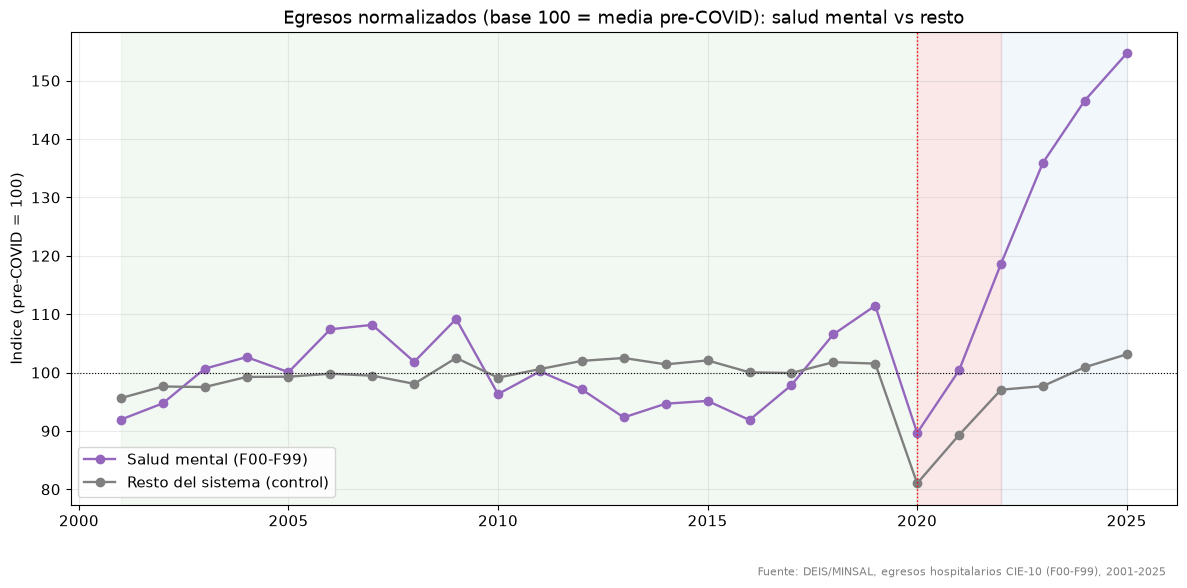

In [7]:
rel_sm = contrafactual(df, 'egresos_sm'); rel_sm = rel_sm[rel_sm['ano'] >= POST_Y]
sm_pct = 100*rel_sm['gap'].mean()/rel_sm['cf'].mean()
rel_ctrl = contrafactual(df, 'egresos_no_sm'); rel_ctrl = rel_ctrl[rel_ctrl['ano'] >= POST_Y]
ctrl_pct = 100*rel_ctrl['gap'].mean()/rel_ctrl['cf'].mean()
did = sm_pct - ctrl_pct
print(f"Salud mental   POST vs esperado: {sm_pct:+.1f}%")
print(f"Resto sistema  POST vs esperado: {ctrl_pct:+.1f}%")
print(f"Diff-in-diff (SM - control)    : {did:+.1f} puntos %")

fig, ax = plt.subplots()
for col_y, lab, c in [('egresos_sm', 'Salud mental (F00-F99)', 'tab:purple'),
                      ('egresos_no_sm', 'Resto del sistema (control)', 'tab:gray')]:
    base = df.loc[df['ano'] < COVID_Y, col_y].mean()
    ax.plot(df['ano'], df[col_y]/base*100, 'o-', lw=1.7, color=c, label=lab)
ax.axhline(100, color='black', lw=0.8, ls=':'); ax.axvline(COVID_Y, color='red', lw=1, ls=':')
zonas(ax, df)
ax.set_title('Egresos normalizados (base 100 = media pre-COVID): salud mental vs resto')
ax.set_ylabel('Indice (pre-COVID = 100)'); ax.legend(loc='lower left'); pie(ax)
fig.tight_layout(); fig.savefig(GRAF / '05_control_did_sm.png', dpi=150, bbox_inches='tight')
plt.show()

## Sección 5 · ¿Qué patologías cambiaron? Desglose por grupo diagnóstico

Ventaja exclusiva de esta capa: ver **qué trastornos** movieron la aguja. Se compara el promedio
anual **pre-COVID (2015-2019)** vs **post-COVID (2022-2024)** por grupo F0-F9.

                                grupo  pre_2015_19  post_2022_24  cambio_%
                   F80-F89 Desarrollo        351.0         720.0     105.4
                 F60-F69 Personalidad       2543.0        4527.0      78.0
 F90-F99 Infancia/adolesc. y sin esp.        609.0        1074.0      76.5
       F50-F59 Sind. comportamentales        422.0         676.0      60.1
F30-F39 Afectivos (depresion/bipolar)       8330.0       12898.0      54.8
              F40-F48 Ansiedad/estres       3274.0        4987.0      52.3
         F00-F09 Organicos (demencia)       1800.0        2189.0      21.6
     F20-F29 Esquizofrenia/psicoticos       5268.0        6023.0      14.3
                   F10-F19 Sustancias       6417.0        5764.0     -10.2
          F70-F79 Discap. intelectual        488.0         369.0     -24.3


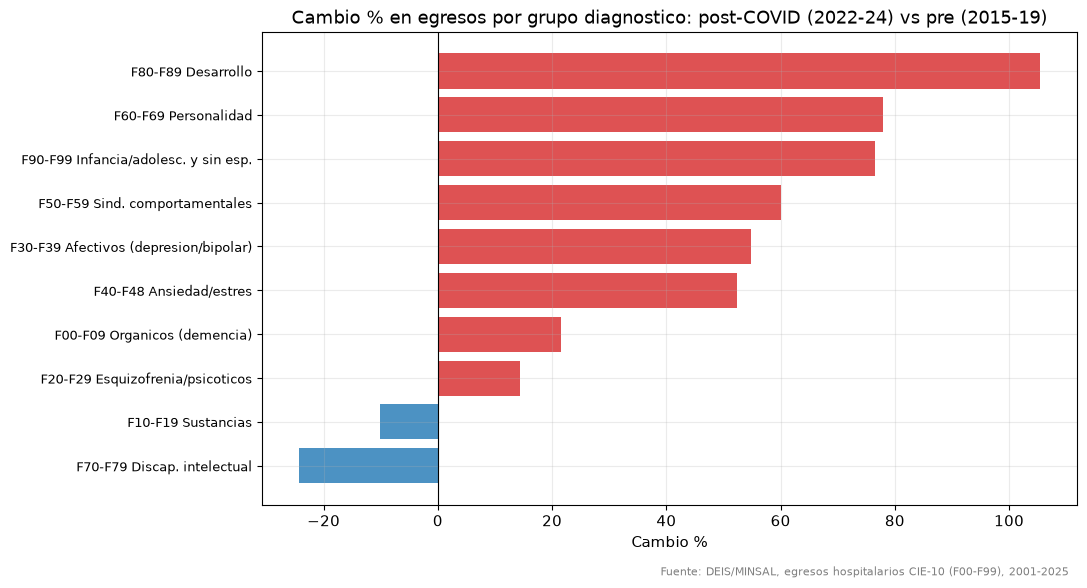

In [8]:
gcols = [g for g in GRUPOS if g in df.columns]
pre = df[(df['ano'] >= 2015) & (df['ano'] <= 2019)][gcols].mean()
post = df[(df['ano'] >= 2022) & (df['ano'] <= 2024)][gcols].mean()
desg = pd.DataFrame({'pre_2015_19': pre.round(0), 'post_2022_24': post.round(0)})
desg['cambio_%'] = (100*(post-pre)/pre).round(1)
desg['grupo'] = [GRUPOS[g] for g in desg.index]
desg = desg.sort_values('cambio_%', ascending=False)
print(desg[['grupo', 'pre_2015_19', 'post_2022_24', 'cambio_%']].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['tab:red' if v > 0 else 'tab:blue' for v in desg['cambio_%']]
ax.barh(range(len(desg)), desg['cambio_%'], color=colors, alpha=0.8)
ax.set_yticks(range(len(desg))); ax.set_yticklabels(desg['grupo'], fontsize=9)
ax.axvline(0, color='black', lw=0.8); ax.invert_yaxis()
ax.set_title('Cambio % en egresos por grupo diagnostico: post-COVID (2022-24) vs pre (2015-19)')
ax.set_xlabel('Cambio %'); pie(ax)
fig.tight_layout(); fig.savefig(GRAF / '06_desglose_dx.png', dpi=150, bbox_inches='tight')
plt.show()

## Sección 6 · Veredicto sobre la hipótesis (Capa 2)

*(Las cifras de esta celda se completan tras ejecutar; el texto se certifica número a número
antes de integrarlo al informe.)*

La pregunta era: **¿el COVID causó el aumento de las patologías psiquiátricas?** A diferencia de
la Capa 1 (hospitalización/camas), aquí medimos **egresos con diagnóstico CIE-10 F00-F99**. Se
contrasta el mismo criterio: ¿hubo un **quiebre de tendencia** en 2020, o la patología seguía
una trayectoria previa? Veredicto y matices se redactan sobre los números reales de arriba,
manteniendo la honestidad del dato (granularidad anual; egreso-por-diagnóstico ≠ incidencia
poblacional).